# 11 — Keeping the Textbook Picture: Design Knobs

[Notebook 10](10_pntoy_Band_Diagrams.ipynb) showed that the pntoy diode's band diagram matches the textbook up to about
0.55 V and then distorts, mainly because the exponentially growing current makes the neutral regions drop part of the
voltage (ohmic drop), while the junction voltage stalls just below $V_{bi}$.
This notebook changes the device one parameter at a time and measures **how far the textbook picture now survives**.

The knobs, and the question each one answers:

| Knob | Intuition to test |
|---|---|
| doping (both sides) | "more doping pushes high injection away" |
| doping (one side only) | "is it enough to fix the lightly doped side?" |
| length of the neutral regions | "a bigger device is better" or "a shorter resistor is better"? |
| area (depth into the page) | "a bigger diode handles more bias" |
| carrier lifetime | "better silicon behaves more ideally" |
| temperature | "does cooling or heating change the limit?" |

**One number per design.** We call the *textbook limit* $V_{90}$ the highest applied bias at which the junction
still receives at least 90% of it ($V_j/V\ge0.9$, measured from the quasi-Fermi levels exactly as in notebook 10).
The pntoy default reaches $V_{90}\approx$ 0.58 V.

**One idea explains most of the results.** The side drops are close to $J\cdot R_s$ (notebook 10, Section 7), so $V_{90}$
is roughly the bias at which $J(V)\,R_s\approx0.1\,V$. You push it up in two ways:
* lower the current at a given voltage, i.e. lower $J_0$;
* lower the series resistance $R_s$ of the neutral regions.

Keep $V_{bi}$ and $V_{HI}=2kT/q\ln(N/n_i)$ in mind as the voltages near which the junction stalls.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────
# PADRE is a compiled simulator. On nanoHUB it lives in an environment
# module that must be loaded into this Python kernel before the first
# simulation runs; elsewhere, PADRE just needs to be on your PATH.
import shutil
from nanohubpadre import use

if shutil.which("padre") is None:
    try:
        use("padre-2.4E-r15")          # nanoHUB module name
    except Exception as exc:           # not on nanoHUB: that is fine
        print("Could not load the PADRE module:", exc)

print("PADRE executable:", shutil.which("padre") or "NOT FOUND - simulations will fail")

PADRE executable: /apps/share64/debian10/padre/padre-2.4E/r15/bin/padre


In [2]:
# ── Physical constants: textbook values vs. the values PADRE really uses ──
# PADRE prints its constants with `MODELS ... PRINT`. A fair comparison of
# simulation against a formula must feed the formula PADRE's numbers:
# e.g. the textbook n_i = 1.5e10 cm^-3 alone changes every analytic diode
# current by (1.5e10 / 9.963e9)^2 = 2.3x before any physics is compared.
import numpy as np

Q      = 1.602e-19        # elementary charge (C)
KT     = 0.025851         # thermal voltage kT/q at 300 K (V)
EPS0   = 8.854e-14        # vacuum permittivity (F/cm)
EPS_SI = 11.8 * EPS0      # silicon permittivity in PADRE (F/cm)
EPS_OX = 3.9 * EPS0       # SiO2 permittivity (F/cm)
NI     = 9.963e9          # intrinsic carrier density of Si at 300 K (cm^-3)
EG     = 1.12             # band gap (eV)
CHI_SI = 4.17             # electron affinity of Si in PADRE (eV)
NC, NV = 3.2e19, 2.03e19  # effective densities of states (cm^-3)

# The values most textbooks quote (e.g. Sze & Ng, Pierret), for contrast.
TEXTBOOK = dict(NI=1.5e10, EPS_SI=11.7 * EPS0, CHI_SI=4.05, NC=2.8e19, NV=1.04e19)


def compare(rows, title="Textbook vs. PADRE"):
    """Print a comparison table.

    rows: list of (quantity, textbook_value, padre_value, unit, why_different)
    """
    print(title)
    print("-" * 125)
    print(f"{'quantity':<40}{'textbook':>12}{'PADRE':>12}{'diff':>9}   why they differ")
    print("-" * 125)
    for name, tb, pd, unit, why in rows:
        d = f"{(pd - tb) / tb * 100:>+8.1f}%" if tb else "     n/a "
        print(f"{name + ' (' + unit + ')':<40}{tb:>12.4g}{pd:>12.4g}{d}   {why}")
    print("-" * 125)


compare([
    ("intrinsic density n_i", TEXTBOOK["NI"], NI, "cm^-3",
     "modern value (Sproul & Green 1991); 1.5e10 is the older textbook number"),
    ("Si permittivity", TEXTBOOK["EPS_SI"], EPS_SI, "F/cm", "PADRE uses eps_r = 11.8, Sze uses 11.7"),
    ("electron affinity chi", TEXTBOOK["CHI_SI"], CHI_SI, "eV", "PADRE (like Silvaco Atlas) uses 4.17"),
    ("conduction-band DOS Nc", TEXTBOOK["NC"], NC, "cm^-3", "different effective-mass fit"),
    ("valence-band DOS Nv", TEXTBOOK["NV"], NV, "cm^-3", "different effective-mass fit"),
], title="Material constants")

Material constants
-----------------------------------------------------------------------------------------------------------------------------
quantity                                    textbook       PADRE     diff   why they differ
-----------------------------------------------------------------------------------------------------------------------------
intrinsic density n_i (cm^-3)                1.5e+10   9.963e+09   -33.6%   modern value (Sproul & Green 1991); 1.5e10 is the older textbook number
Si permittivity (F/cm)                     1.036e-12   1.045e-12    +0.9%   PADRE uses eps_r = 11.8, Sze uses 11.7
electron affinity chi (eV)                      4.05        4.17    +3.0%   PADRE (like Silvaco Atlas) uses 4.17
conduction-band DOS Nc (cm^-3)               2.8e+19     3.2e+19   +14.3%   different effective-mass fit
valence-band DOS Nv (cm^-3)                 1.04e+19    2.03e+19   +95.2%   different effective-mass fit
---------------------------------------------------

In [3]:
# ── The pntoy diode, rebuilt with nanohubpadre ──────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from nanohubpadre import create_pn_diode, Solve


def tag(v):
    """File-name tag for a bias point: 0.35 V -> 'v0350'."""
    return f"v{int(round(v * 1000)):04d}"


def pntoy_diode(p_len=3.0, n_len=6.0, Na=2e15, Nd=1e15, tau=1e-10, vmax=1.0, dv=0.05,
                temperature=300, depth=1.0, nx=400):
    """Silicon p-n diode with the pntoy tool's defaults, and a snapshot of the
    band diagram (Ec, Ev, Efn, Efp) plus carrier profiles at every bias step.

    p_len, n_len : lengths of the p and n regions (um); contacts at both ends
    Na, Nd       : uniform doping (cm^-3);  tau : SRH lifetimes (s)
    vmax, dv     : forward sweep 0 -> vmax on the p contact, in steps of dv (V)
    depth        : device depth into the page (um); currents scale with it
    """
    L = p_len + n_len
    sim = create_pn_diode(length=L, junction_position=p_len / L, p_doping=Na, n_doping=Nd,
                          taun0=tau, taup0=tau, nx=nx, temperature=temperature,
                          device_z_width=depth, log_iv=True)
    biases = np.round(np.arange(0.0, vmax + 1e-9, dv), 6)
    cut = dict(x_start=0.0, y_start=0.5, x_end=L, y_end=0.5)    # line through the middle
    sim.add_solve(Solve(initial=True))                            # equilibrium
    for k, v in enumerate(biases):
        if k > 0:   # one small step at a time, starting from the previous solution
            sim.add_solve(Solve(previous=True, v1=float(v), electrode=1))
        sim.log_band_diagram(tag(v), include_qf=True, **cut)      # Ec, Ev, Efn, Efp
        sim.log_physics(tag(v), **cut)                            # n, p, E-field, recombination
    sim.meta = dict(p_len=p_len, n_len=n_len, Na=Na, Nd=Nd, tau=tau, L=L, xj=p_len,
                    biases=biases, T=temperature, depth=depth)
    return sim


def snapshot(sim, v):
    """All profiles at bias v, as arrays along x (um). Energies in eV, densities in cm^-3."""
    t, g = tag(v), sim.outputs.get
    ec = g("cb" + t)
    return dict(x=ec.x, ec=ec.y, ev=g("vb" + t).y, fn=g("qfn" + t).y, fp=g("qfp" + t).y,
                n=np.abs(g("n_" + t).y), p=np.abs(g("p_" + t).y), ef=g("efield_" + t).y)


def voltage_budget(sim):
    """Split every applied bias V into  V = V_junction + V_p-side + V_n-side.

    V_junction : Efn - Efp at the metallurgical junction (textbook: all of V)
    V_p-side   : drop of the hole quasi-Fermi level from the p contact to the junction
    V_n-side   : drop of the electron quasi-Fermi level from the n contact to the junction
    """
    xj, rows = sim.meta["xj"], []
    for v in sim.meta["biases"]:
        s = snapshot(sim, v)
        fn_j, fp_j = np.interp(xj, s["x"], s["fn"]), np.interp(xj, s["x"], s["fp"])
        rows.append((v, fn_j - fp_j, fp_j - s["fp"][0], s["fn"][-1] - fn_j))
    return np.array(rows).T      # V, Vj, Vp, Vn


def fidelity_limit(V, Vj, level=0.9):
    """Highest bias at which the junction still receives `level` of the applied voltage."""
    f = np.where(V > 0, Vj / np.maximum(V, 1e-12), 1.0)
    k = np.where(f < level)[0]
    if len(k) == 0:
        return np.inf
    k = k[0]
    return V[k - 1] + (f[k - 1] - level) / (f[k - 1] - f[k]) * (V[k] - V[k - 1])

In [4]:
RESULTS = {}

def study(name, **kw):
    # run one design to 1.0 V and store its voltage budget, current and textbook limit
    sim = pntoy_diode(**kw)
    res = sim.run()
    assert res.returncode == 0, (name, res.stdout[-1500:])
    V, Vj, Vp, Vn = voltage_budget(sim)
    I = sim.get_iv_data().get_currents(1)
    s0 = snapshot(sim, 0.0)
    ni_T = float(np.sqrt(s0["n"][0] * s0["p"][0]))             # PADRE's n_i at this temperature
    m = sim.meta
    kT = KT * m["T"] / 300
    r = dict(sim=sim, V=V, Vj=Vj, Vp=Vp, Vn=Vn, J=I * 1e8 / m["depth"], I=I, ni=ni_T,
             V90=fidelity_limit(V, Vj), vbi=kT * np.log(m["Na"] * m["Nd"] / ni_T ** 2),
             vhi=2 * kT * np.log(min(m["Na"], m["Nd"]) / ni_T), meta=m)
    RESULTS[name] = r
    print(f"{name:<24} V90 = {r['V90']:.3f} V   Vbi = {r['vbi']:.3f} V   V_HI(light side) = {r['vhi']:.3f} V   "
          f"J(0.6 V) = {np.interp(0.6, V, r['J']):.3g} A/cm2")
    return r


def fidelity_plot(names, title):
    fig, ax = plt.subplots(figsize=(8, 4.3))
    for nm in names:
        r = RESULTS[nm]
        f = np.where(r["V"] > 0, r["Vj"] / np.maximum(r["V"], 1e-12), 1) * 100
        ax.plot(r["V"], f, "o-", ms=3, label=f"{nm}  (V90 = {r['V90']:.2f} V)")
    ax.axhline(90, color="gray", ls="--")
    ax.set(xlabel="applied V (V)", ylabel="$V_j/V$ (%)", title=title, ylim=(30, 102))
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


base = study("pntoy default")

Using cached results from '/tmp/nbrun_padre/pn_junction_diode_db5e0ca3a165d32947a5d792e88209a3'
pntoy default            V90 = 0.585 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 14.2 A/cm2


---
## 1. Doping both sides

**Prediction.** Higher doping helps three ways at once:
* $V_{HI}=\frac{2kT}{q}\ln\frac{N}{n_i}$ rises by $2kT/q\cdot\ln10$ = 0.119 V per decade of doping;
* $V_{bi}$ rises by the same 0.119 V per decade (both dopings ×10);
* the neutral-region resistivity falls roughly 10× per decade.

doping x10               V90 = 0.734 V   Vbi = 0.732 V   V_HI(light side) = 0.714 V   J(0.6 V) = 14.2 A/cm2
doping x100              V90 = 0.867 V   Vbi = 0.851 V   V_HI(light side) = 0.834 V   J(0.6 V) = 2.37 A/cm2


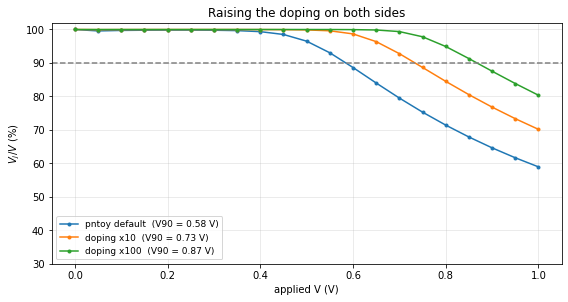

In [5]:
study("doping x10", Na=2e16, Nd=1e16)
study("doping x100", Na=2e17, Nd=1e17)
fidelity_plot(["pntoy default", "doping x10", "doping x100"], "Raising the doping on both sides")

**Result.** This is the strongest knob: +0.15 V for the first decade and +0.13 V for the second. It works on both halves
of $J\,R_s$ at once. $J_0\propto1/N$ falls, and so does $R_s\propto1/N\mu$. $V_{90}$ stays within 0.01–0.03 V of
$V_{HI}$ of the lighter side, and of $V_{bi}$.

**The price.** A more heavily doped junction has a lower avalanche breakdown voltage (about 300 V at 10¹⁵ cm⁻³, 60 V at
10¹⁶, 12 V at 10¹⁷ for a one-sided Si junction; Sze & Ng Fig. 2.25), a larger junction capacitance
($C\propto\sqrt N$), and a smaller current at the same voltage ($J_0\propto1/N$). Above ~10¹⁸ cm⁻³ band-gap
narrowing appears, and near 10¹⁹ cm⁻³ tunnelling, which this model does not include.

---
## 2. Doping one side only

**Prediction.** The lightly doped side reaches high injection first and has the higher resistance. Raising only the
heavy side should therefore help less than raising both, but it still raises $V_{bi}$ by $kT/q\ln100$ = 0.12 V.

p side x100              V90 = 0.634 V   Vbi = 0.732 V   V_HI(light side) = 0.595 V   J(0.6 V) = 16.7 A/cm2
n side x100              V90 = 0.647 V   Vbi = 0.732 V   V_HI(light side) = 0.631 V   J(0.6 V) = 21.3 A/cm2


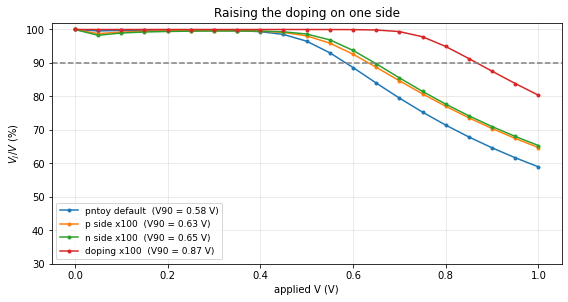

In [6]:
study("p side x100", Na=2e17)
study("n side x100", Nd=1e17)
fidelity_plot(["pntoy default", "p side x100", "n side x100", "doping x100"], "Raising the doping on one side")

**Result.** Either one-sided change helps, by +0.05 V (p side) or +0.06 V (n side), a fifth of the two-sided +0.28 V.
The unchanged side keeps its resistance and still dominates $J_0$, so $V_{90}$ ends up only just above that side's
$V_{HI}$ (0.60–0.63 V), although $V_{bi}$ rose by 0.12 V. A one-sided (p⁺n or n⁺p) junction is the usual device design,
and its textbook region is set by the **lightly doped side**.

---
## 3. The length of the neutral regions

**Prediction.** Two effects pull in opposite directions:
* the neutral regions are resistors, so a **longer** device has more ohmic drop, and a shorter one less;
* in a shorter device, the contacts sit closer to the junction and extract injected carriers faster. The diode becomes
  "short base" and carries **more current** at the same voltage, which raises the ohmic drop again.

With τ = 0.1 ns the diffusion lengths are only 0.3–0.6 µm, so at low bias the pntoy diode is long-base and its current
barely depends on the length until the regions are shorter than ~1 µm.

short 0.6/1.2 um         V90 = 0.653 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 46.8 A/cm2
1.5/3 um                 V90 = 0.614 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 23.3 A/cm2
long 6/12 um             V90 = 0.556 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 8.66 A/cm2


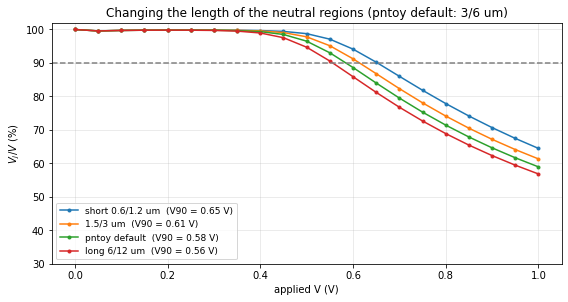

short 0.6/1.2 um   J(0.8 V) =      375 A/cm2   side drops at 0.8 V: p 0.055 V, n 0.122 V
1.5/3 um           J(0.8 V) =      109 A/cm2   side drops at 0.8 V: p 0.075 V, n 0.132 V
pntoy default      J(0.8 V) =     50.9 A/cm2   side drops at 0.8 V: p 0.093 V, n 0.136 V
long 6/12 um       J(0.8 V) =     26.1 A/cm2   side drops at 0.8 V: p 0.105 V, n 0.144 V


In [7]:
study("short 0.6/1.2 um", p_len=0.6, n_len=1.2)
study("1.5/3 um", p_len=1.5, n_len=3.0)
study("long 6/12 um", p_len=6.0, n_len=12.0)
fidelity_plot(["short 0.6/1.2 um", "1.5/3 um", "pntoy default", "long 6/12 um"],
              "Changing the length of the neutral regions (pntoy default: 3/6 um)")
for nm in ["short 0.6/1.2 um", "1.5/3 um", "pntoy default", "long 6/12 um"]:
    r = RESULTS[nm]
    print(f"{nm:<18} J(0.8 V) = {np.interp(0.8, r['V'], r['J']):8.3g} A/cm2   "
          f"side drops at 0.8 V: p {np.interp(0.8, r['V'], r['Vp']):.3f} V, n {np.interp(0.8, r['V'], r['Vn']):.3f} V")

**Result.** Length is a moderate knob, and it works the opposite way to "bigger is better". Making the neutral regions 5×
shorter gains +0.07 V; making them 2× longer loses 0.03 V. A longer neutral region is simply a longer resistor, and it
gains nothing in return, because the current is set by the diffusion length, not by the device length.

Notice also that shortening the device raises the current 7× at 0.8 V, because it becomes short-base, yet the side drops
still fall. The resistance falls faster than the current rises.

**The price of short.** At equilibrium the depletion region already extends 0.73 µm into the n side. A 1.2 µm n region
leaves under 0.5 µm of neutral silicon, and in reverse bias the depletion region reaches the contact (*punch-through*)
at only a few volts.

---
## 4. The area of the diode

**Prediction.** A 1-D simulation describes one column of the device. Making the diode wider or deeper adds identical columns
side by side. The total current grows in proportion, but the current *density*, and with it every band diagram, stays the same.

In [8]:
study("depth x10", depth=10.0)
b, d = RESULTS["pntoy default"], RESULTS["depth x10"]
print(f"\ntotal current at 0.8 V: {np.interp(0.8, b['V'], b['I']):.3e} A (depth 1 um) vs "
      f"{np.interp(0.8, d['V'], d['I']):.3e} A (depth 10 um)")
print(f"largest difference in V_j between the two: {np.max(np.abs(b['Vj'] - d['Vj'])) * 1e3:.3f} mV")

depth x10                V90 = 0.585 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 14.2 A/cm2

total current at 0.8 V: 5.088e-07 A (depth 1 um) vs 5.088e-06 A (depth 10 um)
largest difference in V_j between the two: 0.000 mV


**Result.** The current is exactly 10× larger, and the voltage budget is identical to the microvolt. "A bigger diode" does not
push the textbook limit anywhere. In a real, large-area diode, the extra current can make things *worse*,
through resistance in the metal, the contacts and the substrate, which this 1-D model leaves out.

---
## 5. Carrier lifetime

**Prediction.** A longer lifetime means less recombination, so less current at the same voltage and less ohmic drop.
It does not change $V_{bi}$ or $V_{HI}$, which depend only on doping and temperature.

tau 10 ns                V90 = 0.684 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 8.12 A/cm2
tau 1 us                 V90 = 0.697 V   Vbi = 0.613 V   V_HI(light side) = 0.595 V   J(0.6 V) = 7.73 A/cm2


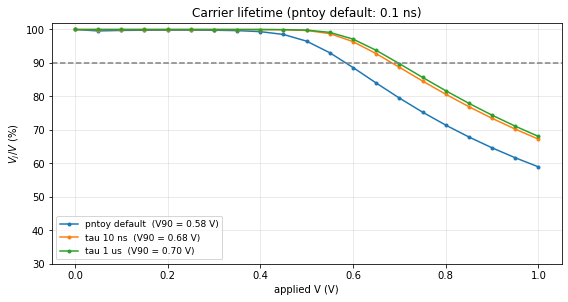

In [9]:
study("tau 10 ns", tau=1e-8)
study("tau 1 us", tau=1e-6)
fidelity_plot(["pntoy default", "tau 10 ns", "tau 1 us"], "Carrier lifetime (pntoy default: 0.1 ns)")

**Result.** Better silicon helps: +0.10 V at 10 ns and +0.11 V at 1 µs. The current at a given voltage halves, so less
voltage is lost in the resistors. The gain saturates once the diffusion lengths exceed the neutral widths (τ ≳ 10 ns
here), because the diode then becomes short-base and the current stops falling. At 1 µs $V_{90}$ = 0.70 V, and the
junction receives about 0.63 V, *more* than $V_{bi}$: the $V_{bi}$ wall is soft, and what finally stops the junction
voltage is the resistor.

---
## 6. Temperature

**Prediction.** $n_i$ rises steeply with temperature ($n_i\propto T^{3/2}e^{-E_g/2kT}$), so $V_{bi}$ and $V_{HI}$ both
**fall** when the device heats up and **rise** when it cools. The mobility changes too, but more slowly.

250 K                    V90 = 0.740 V   Vbi = 0.722 V   V_HI(light side) = 0.707 V   J(0.6 V) = 1.75 A/cm2
400 K                    V90 = 0.208 V   Vbi = 0.387 V   V_HI(light side) = 0.363 V   J(0.6 V) = 32.4 A/cm2


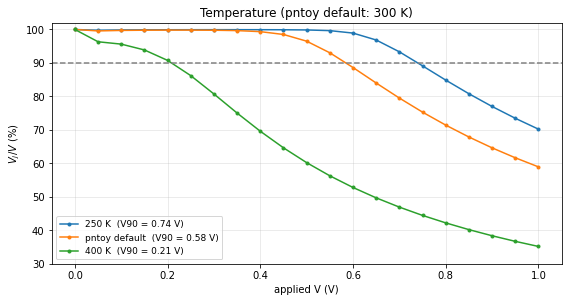

250 K          n_i = 7.514e+07 cm^-3   Vbi = 0.722 V   V_HI = 0.707 V   V90 = 0.740 V
pntoy default  n_i = 9.963e+09 cm^-3   Vbi = 0.613 V   V_HI = 0.595 V   V90 = 0.585 V
400 K          n_i = 5.146e+12 cm^-3   Vbi = 0.387 V   V_HI = 0.363 V   V90 = 0.208 V


In [10]:
study("250 K", temperature=250)
study("400 K", temperature=400)
fidelity_plot(["250 K", "pntoy default", "400 K"], "Temperature (pntoy default: 300 K)")
for nm in ["250 K", "pntoy default", "400 K"]:
    r = RESULTS[nm]
    print(f"{nm:<14} n_i = {r['ni']:.3e} cm^-3   Vbi = {r['vbi']:.3f} V   V_HI = {r['vhi']:.3f} V   V90 = {r['V90']:.3f} V")

**Result.** Temperature is at least as strong as a decade of doping, in either direction. At 250 K the limit rises by
+0.16 V, as much as doping ×10 gives. At 400 K $n_i$ is about 500× larger, $V_{bi}$ falls to 0.39 V, and the textbook picture
holds only to 0.21 V, far below even that temperature's $V_{HI}$ (0.36 V). $J_0\propto n_i^2$ has grown ~2.7×10⁵-fold,
so the $J\,R_s$ term bites at a much lower voltage. This is one reason power diodes that heat up under load lose their ideal
behaviour sooner.

---
## 7. Side by side at 0.8 V

The pntoy default next to the best of the "cheap" fixes (doping ×100). Same applied voltage, very different pictures.

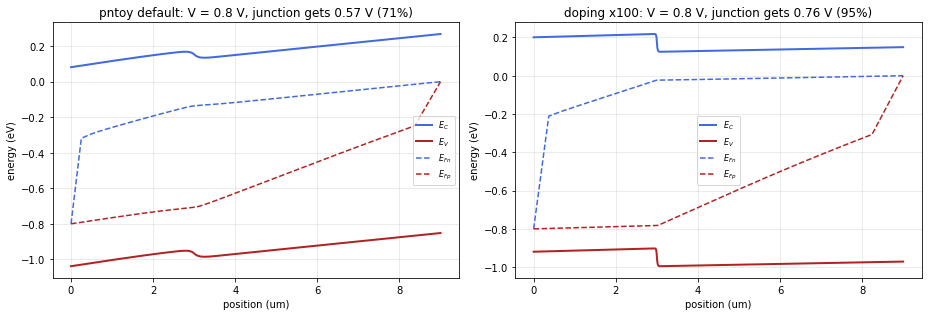

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, nm in zip(axes, ["pntoy default", "doping x100"]):
    r = RESULTS[nm]; s = snapshot(r["sim"], 0.8); k = np.argmin(abs(r["V"] - 0.8))
    ax.plot(s["x"], s["ec"], color="royalblue", lw=2, label="$E_C$")
    ax.plot(s["x"], s["ev"], color="firebrick", lw=2, label="$E_V$")
    ax.plot(s["x"], s["fn"], color="royalblue", ls="--", label="$E_{Fn}$")
    ax.plot(s["x"], s["fp"], color="firebrick", ls="--", label="$E_{Fp}$")
    ax.set(title=f"{nm}: V = 0.8 V, junction gets {r['Vj'][k]:.2f} V ({r['Vj'][k] / 0.8 * 100:.0f}%)",
           xlabel="position (um)", ylabel="energy (eV)")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

At 0.8 V the doping-×100 diode still looks like a textbook drawing: flat neutral bands and quasi-Fermi levels split by
more than 90% of 0.8 eV. The pntoy default at the same voltage has tilted neutral regions and a junction that receives
only about 70% of the bias.

---
## 8. Summary: which knobs keep the textbook picture?

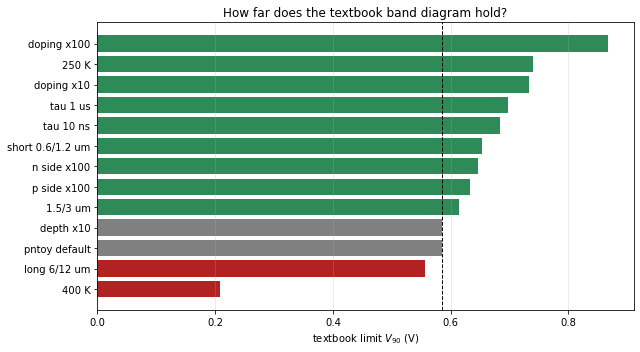

design                    V90 (V)  Vbi (V)  V_HI light (V)   J(0.6V) A/cm2
doping x100                 0.867    0.851           0.834            2.37
250 K                       0.740    0.722           0.707            1.75
doping x10                  0.734    0.732           0.714            14.2
tau 1 us                    0.697    0.613           0.595            7.73
tau 10 ns                   0.684    0.613           0.595            8.12
short 0.6/1.2 um            0.653    0.613           0.595            46.8
n side x100                 0.647    0.732           0.631            21.3
p side x100                 0.634    0.732           0.595            16.7
1.5/3 um                    0.614    0.613           0.595            23.3
depth x10                   0.585    0.613           0.595            14.2
pntoy default               0.585    0.613           0.595            14.2
long 6/12 um                0.556    0.613           0.595            8.66
400 K                    

In [12]:
names = list(RESULTS)
v90 = [RESULTS[n]["V90"] for n in names]
order = np.argsort(v90)
fig, ax = plt.subplots(figsize=(9, 5))
cols = ["firebrick" if RESULTS[names[i]]["V90"] < base["V90"] - 0.01 else
        "seagreen" if RESULTS[names[i]]["V90"] > base["V90"] + 0.01 else "gray" for i in order]
ax.barh([names[i] for i in order], [v90[i] for i in order], color=cols)
ax.axvline(base["V90"], color="black", ls="--", lw=1)
ax.set(xlabel="textbook limit $V_{90}$ (V)", title="How far does the textbook band diagram hold?")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

print(f"{'design':<24}{'V90 (V)':>9}{'Vbi (V)':>9}{'V_HI light (V)':>16}{'J(0.6V) A/cm2':>16}")
for i in order[::-1]:
    r = RESULTS[names[i]]
    print(f"{names[i]:<24}{r['V90']:>9.3f}{r['vbi']:>9.3f}{r['vhi']:>16.3f}{np.interp(0.6, r['V'], r['J']):>16.3g}")

| Knob | Effect on the textbook limit | Why | Trade-off |
|---|---|---|---|
| doping, both sides ×10 / ×100 | **strong**: +0.15 / +0.28 V | lowers $J_0$ and $R_s$; raises $V_{HI}$, $V_{bi}$ | lower breakdown voltage, more capacitance |
| doping, one side ×100 | weak: +0.05 to +0.06 V | light side keeps $J_0$ and $R_s$ | — |
| neutral regions 5× shorter | moderate: +0.07 V | shorter resistor (despite 7× more current) | punch-through in reverse bias |
| neutral regions 2× longer | slightly worse: −0.03 V | longer resistor, same current | — |
| area / depth ×10 | **none** (0.000 mV) | $J$ and $R_sA$ unchanged | 10× more total current |
| lifetime 10 ns / 1 µs | moderate: +0.10 / +0.11 V, saturates | half the current, half the IR drop | — |
| cooler (250 K) | strong: +0.16 V | $n_i$ 130× smaller: much lower $J_0$ | — |
| hotter (400 K) | **strongly worse**: −0.38 V | $n_i$ 500× larger: $J_0$ up 10⁵× | — |

**Rule of thumb.** The textbook band diagram of a p-n junction holds while the ohmic drop $J\cdot R_s$ in the neutral
regions stays small compared with the applied voltage (≲ 10%). With the exponential current, that happens close to
$V_{HI}$ of the **lightly doped side** for ordinary diodes. But a large $J_0$ (hot device, short lifetime) or a large $R_s$
(long, lightly doped regions) pulls the limit lower. Doping and temperature are the strong knobs; length and lifetime are
moderate; area does nothing.

---
## 9. Exercises
1. **Design to a target.** Find the lowest uniform doping (same on both sides) that keeps $V_{90}\ge$ 0.8 V. Check your
   guess against $V_{HI}=2kT/q\ln(N/n_i)$ first.
2. **Combine knobs.** Do the doping and lifetime improvements add up? Run `pntoy_diode(Na=2e16, Nd=1e16, tau=1e-6)`.
3. **The PIN alternative.** A PIN diode is designed to operate in high injection. Build one with
   `create_pn_diode(intrinsic_width=...)` and look at its band diagram at 0.8 V. Is it "distorted", or is high injection
   the normal state of this device?
4. **Back to pntoy.** In the [pntoy tool](https://nanohub.org/tools/pntoy), set $N_A=N_D$ = 10¹⁷ cm⁻³ and sweep to 0.8 V.
   Compare its last band diagram with Section 7.

**Back to →** [00 — Introduction](00_Introduction.ipynb)